In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../data/cleaned_data.csv")

# Convert to numeric
cols = ["prob_true", "anti_party", "pro_party", "good_news", "bad_news"]
for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Keep rows used in this figure
plot_df = df.dropna(subset=cols).copy()

# 只保留 good news / bad news
plot_df = plot_df[
    (plot_df["good_news"] + plot_df["bad_news"] > 0)
].copy()

plot_df["group"] = pd.Series(pd.NA, index=plot_df.index, dtype="object")

# Anti-party
plot_df.loc[
    (plot_df["anti_party"] == 1) & (plot_df["politicized_true"] == 0),
    "group"
] = "Anti-Party,\nFake News"

plot_df.loc[
    (plot_df["anti_party"] == 1) & (plot_df["politicized_true"] == 1),
    "group"
] = "Anti-Party,\nTrue News"

# Neutral
plot_df.loc[
    (plot_df["anti_party"] == 0) &
    (plot_df["pro_party"] == 0) &
    (plot_df["fake_news"] == 1),
    "group"
] = "Neutral,\nFake News"

plot_df.loc[
    (plot_df["anti_party"] == 0) &
    (plot_df["pro_party"] == 0) &
    (plot_df["true_news"] == 1),
    "group"
] = "Neutral,\nTrue News"

# Pro-party
plot_df.loc[
    (plot_df["pro_party"] == 1) & (plot_df["politicized_true"] == 0),
    "group"
] = "Pro-Party,\nFake News"

plot_df.loc[
    (plot_df["pro_party"] == 1) & (plot_df["politicized_true"] == 1),
    "group"
] = "Pro-Party,\nTrue News"

plot_df = plot_df.dropna(subset=["group"]).copy()

print(plot_df["group"].value_counts())



group
Anti-Party,\nTrue News    2624
Pro-Party,\nFake News     2592
Pro-Party,\nTrue News     1349
Anti-Party,\nFake News    1337
Neutral,\nFake News        509
Neutral,\nTrue News        471
Name: count, dtype: int64


In [9]:
group_order = [
    "Anti-Party,\nFake News",
    "Anti-Party,\nTrue News",
    "Neutral,\nFake News",
    "Neutral,\nTrue News",
    "Pro-Party,\nFake News",
    "Pro-Party,\nTrue News"
]

overall_mean = plot_df["prob_true"].mean()

summary = (
    plot_df
    .groupby("group")["prob_true"]
    .agg(["mean", "count", "std"])
    .reindex(group_order)
    .reset_index()
)

summary["demeaned_mean"] = summary["mean"] - overall_mean
summary["se"] = summary["std"] / np.sqrt(summary["count"])
summary["ci95"] = 1.96 * summary["se"]

print(summary)


                    group      mean  count       std  demeaned_mean        se  \
0  Anti-Party,\nFake News  0.545400   1337  0.249632      -0.031688  0.006827   
1  Anti-Party,\nTrue News  0.520579   2624  0.241429      -0.056509  0.004713   
2     Neutral,\nFake News  0.612967    509  0.260052       0.035878  0.011527   
3     Neutral,\nTrue News  0.586837    471  0.264569       0.009748  0.012191   
4   Pro-Party,\nFake News  0.635069   2592  0.246443       0.057981  0.004841   
5   Pro-Party,\nTrue News  0.590067   1349  0.238484       0.012978  0.006493   

       ci95  
0  0.013381  
1  0.009238  
2  0.022592  
3  0.023894  
4  0.009488  
5  0.012727  


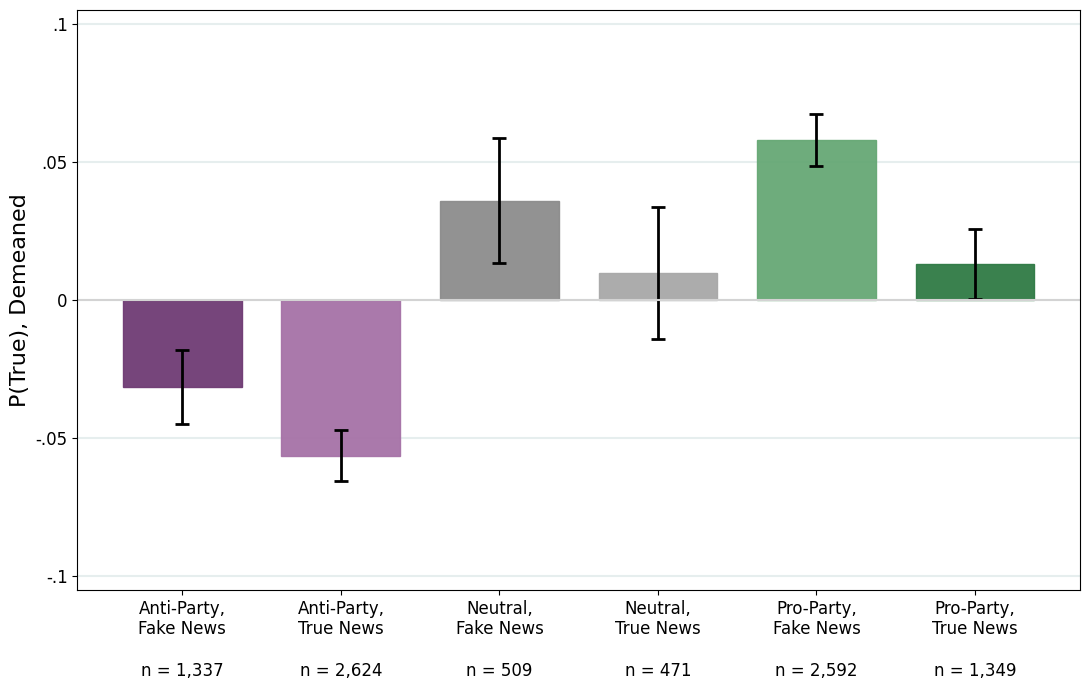

In [10]:
x = np.arange(len(summary))

colors = [
    "#6f3b74",
    "#a672a7",
    "#8c8c8c",
    "#a8a8a8",
    "#66a875",
    "#2f7a44"
]

labels = [
    f"Anti-Party,\nFake News\n\nn = {int(summary.loc[0, 'count']):,}",
    f"Anti-Party,\nTrue News\n\nn = {int(summary.loc[1, 'count']):,}",
    f"Neutral,\nFake News\n\nn = {int(summary.loc[2, 'count']):,}",
    f"Neutral,\nTrue News\n\nn = {int(summary.loc[3, 'count']):,}",
    f"Pro-Party,\nFake News\n\nn = {int(summary.loc[4, 'count']):,}",
    f"Pro-Party,\nTrue News\n\nn = {int(summary.loc[5, 'count']):,}"
]

plt.figure(figsize=(11, 7))

plt.bar(
    x,
    summary["demeaned_mean"],
    color=colors,
    edgecolor=colors,
    width=0.75,
    alpha=0.95
)

plt.errorbar(
    x,
    summary["demeaned_mean"],
    yerr=summary["ci95"],
    fmt="none",
    ecolor="black",
    elinewidth=2,
    capsize=5,
    capthick=2
)

plt.axhline(0, color="lightgray", linewidth=1.5)

plt.xticks(x, labels, fontsize=12)

plt.yticks(
    [-0.10, -0.05, 0, 0.05, 0.10],
    ["-.1", "-.05", "0", ".05", ".1"],
    fontsize=12
)

plt.ylabel("P(True), Demeaned", fontsize=16)
plt.ylim(-0.105, 0.105)

plt.grid(axis="y", color="#e6eeee", linewidth=1.5)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()